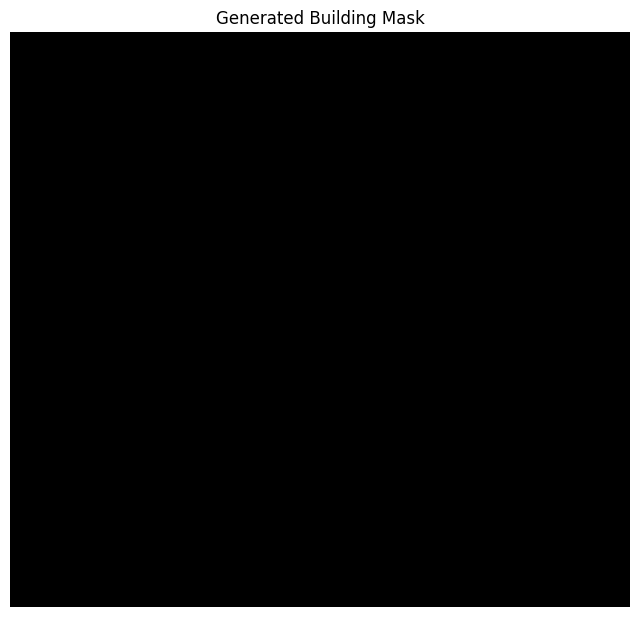

Mask successfully saved to: ./SpaceNet1/train/masks\mask_AOI_1_RIO_img1.tif


In [2]:
import os
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import numpy as np
import matplotlib.pyplot as plt

def create_binary_mask(tif_path, geojson_path, output_path=None):
    # Load the satellite image metadata
    with rasterio.open(tif_path) as src:
        meta = src.meta.copy()
        transform = src.transform
        shape = (src.height, src.width)
    
    # Load the building footprints
    gdf = gpd.read_file(geojson_path)
    
    # Rasterize the polygons (1 for building, 0 for background)
    if not gdf.empty:
        shapes = ((geom, 1) for geom in gdf.geometry)
        mask = rasterize(shapes, out_shape=shape, transform=transform, fill=0, dtype='uint8')
    else:
        mask = np.zeros(shape, dtype='uint8')
        
    # Optional: Save the mask as a new TIFF
    if output_path:
        meta.update(count=1, dtype='uint8')
        with rasterio.open(output_path, 'w', **meta) as out:
            out.write(mask, 1)
            
    return mask

# --- Setup Paths ---
my_tif = './SpaceNet1/train/3band/3band_AOI_1_RIO_img1.tif'
my_geojson = './SpaceNet1/train/geojson/Geo_AOI_1_RIO_img1.geojson'

# Define the output directory and create it if it doesn't exist
output_dir = './SpaceNet1/train/masks'
os.makedirs(output_dir, exist_ok=True)

# Define the exact output file path
my_output_path = os.path.join(output_dir, 'mask_AOI_1_RIO_img1.tif')

# --- Run Function ---
mask = create_binary_mask(my_tif, my_geojson, output_path=my_output_path)

# --- Visualize Result ---
plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap='gray')
plt.title("Generated Building Mask")
plt.axis('off')
plt.show()

print(f"Mask successfully saved to: {my_output_path}")

In [3]:
# --- CRS Diagnostic Check ---
import rasterio
import geopandas as gpd

with rasterio.open('./SpaceNet1/train/3band/3band_AOI_1_RIO_img1.tif') as src:
    print("TIF CRS:", src.crs)
    print("TIF bounds:", src.bounds)

gdf = gpd.read_file('./SpaceNet1/train/geojson/Geo_AOI_1_RIO_img1.geojson')
print("GeoJSON CRS:", gdf.crs)
print("GeoJSON bounds:", gdf.total_bounds)
print("Number of buildings:", len(gdf))

TIF CRS: EPSG:4326
TIF bounds: BoundingBox(left=-43.7751962531, bottom=-22.9233216173, right=-43.7732299921, top=-22.9215002722)
GeoJSON CRS: EPSG:4326
GeoJSON bounds: [nan nan nan nan]
Number of buildings: 0


In [4]:
import os
from tqdm import tqdm # Changed this line to use the standard text progress bar!

# 1. Set up your directories based on your VS Code workspace
band3_dir = './SpaceNet1/train/3band'
geojson_dir = './SpaceNet1/train/geojson'
output_dir = './SpaceNet1/train/masks'

# 2. Get a list of all the .tif images in your 3band folder
image_files = [f for f in os.listdir(band3_dir) if f.endswith('.tif')]
print(f"Found {len(image_files)} images to process. Starting batch masking...")

# 3. Loop through every single file and process it
for img_name in tqdm(image_files, desc="Generating Masks"):
    tif_path = os.path.join(band3_dir, img_name)
    
    # Figure out the exact matching GeoJSON name
    geojson_name = img_name.replace('3band', 'Geo').replace('.tif', '.geojson')
    geojson_path = os.path.join(geojson_dir, geojson_name)
    
    # Figure out the output mask name
    mask_name = img_name.replace('3band', 'mask')
    output_path = os.path.join(output_dir, mask_name)
    
    # 4. Run the function (only if the GeoJSON actually exists!)
    if os.path.exists(geojson_path):
        try:
            create_binary_mask(tif_path, geojson_path, output_path=output_path)
        except Exception as e:
            print(f"Error processing {img_name}: {e}")

print("\nBatch processing complete! All your masks are ready. 🚀")

Found 6940 images to process. Starting batch masking...


Generating Masks: 100%|██████████| 6940/6940 [05:00<00:00, 23.09it/s]


Batch processing complete! All your masks are ready. 🚀


In [5]:
# --- Find an image that actually has buildings ---
import os
import geopandas as gpd

geojson_dir = './SpaceNet1/train/geojson'

for fname in os.listdir(geojson_dir)[:20]:  # check first 20
    path = os.path.join(geojson_dir, fname)
    gdf = gpd.read_file(path)
    if len(gdf) > 0:
        print(f"✅ {fname} has {len(gdf)} buildings")
        break

✅ Geo_AOI_1_RIO_img1009.geojson has 1 buildings


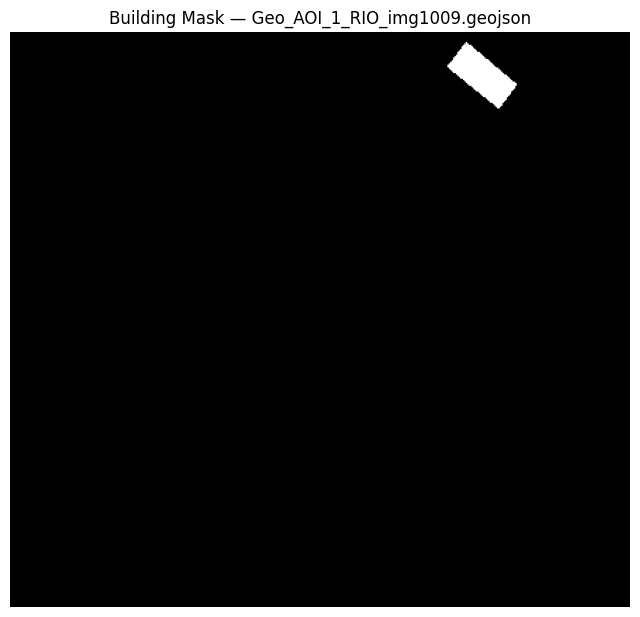

Unique values: [0 1]
Building pixels: 1045
Mask shape: (406, 438)


In [6]:
# --- Visualize a mask that has buildings ---
# Replace the filename below with whatever Cell 3 printed
import numpy as np
import matplotlib.pyplot as plt

found_geojson = 'Geo_AOI_1_RIO_img1009.geojson'  # ← update this after Cell 3 runs

img_id = found_geojson.replace('Geo_', '3band_').replace('.geojson', '.tif')

my_tif     = f'./SpaceNet1/train/3band/{img_id}'
my_geojson = f'./SpaceNet1/train/geojson/{found_geojson}'

mask = create_binary_mask(my_tif, my_geojson)

plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap='gray')
plt.title(f"Building Mask — {found_geojson}")
plt.axis('off')
plt.show()

print(f"Unique values: {np.unique(mask)}")        # should print [0 1]
print(f"Building pixels: {mask.sum()}")           # should be > 0
print(f"Mask shape: {mask.shape}")

In [7]:
# --- PyTorch Dataset Class ---
import torch
from torch.utils.data import Dataset
import rasterio
import numpy as np
import os

class SpaceNetDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # Get all image filenames
        self.image_files = sorted([
            f for f in os.listdir(image_dir) if f.endswith('.tif')
        ])
        
        # Only keep images that have a corresponding mask
        self.valid_pairs = []
        for img_name in self.image_files:
            mask_name = img_name.replace('3band', 'mask')
            mask_path = os.path.join(mask_dir, mask_name)
            if os.path.exists(mask_path):
                self.valid_pairs.append((img_name, mask_name))
        
        print(f"✅ Found {len(self.valid_pairs)} valid image-mask pairs")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.valid_pairs[idx]
        
        # Load image
        img_path = os.path.join(self.image_dir, img_name)
        with rasterio.open(img_path) as src:
            image = src.read([1, 2, 3]).astype(np.float32)  # (3, H, W)
            image = image / 255.0  # normalize to [0, 1]
        
        # Load mask
        mask_path = os.path.join(self.mask_dir, mask_name)
        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)
        
        # Apply transforms if any
        if self.transform:
            # Convert to HWC for albumentations
            image = np.transpose(image, (1, 2, 0))
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']   # back to tensor (3, H, W)
            mask = augmented['mask']     # tensor (H, W)
        else:
            image = torch.tensor(image)  # (3, H, W)
            mask = torch.tensor(mask)    # (H, W)
        
        return image, mask.unsqueeze(0)  # mask → (1, H, W)

In [8]:
# --- Augmentation Pipeline (FIXED with Resize) ---
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 400  # standard SpaceNet tile size

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),         # ← fix: force same size
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),         # ← fix: force same size
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

print("✅ Augmentation pipelines ready (with resize)")

c:\IDEAS_OverheadImageUndersatnding\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Augmentation pipelines ready (with resize)


In [9]:
# --- Create Dataset and DataLoaders ---
from torch.utils.data import DataLoader, random_split

image_dir = './SpaceNet1/train/3band'
mask_dir  = './SpaceNet1/train/masks'

# Create full dataset
full_dataset = SpaceNetDataset(
    image_dir=image_dir,
    mask_dir=mask_dir,
    transform=train_transform
)

# 80/20 train-validation split
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,    # set 0 for Windows
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,    # set 0 for Windows
    pin_memory=True
)

print(f"✅ Train samples : {len(train_dataset)}")
print(f"✅ Val samples   : {len(val_dataset)}")
print(f"✅ Train batches : {len(train_loader)}")
print(f"✅ Val batches   : {len(val_loader)}")

✅ Found 6940 valid image-mask pairs
✅ Train samples : 5552
✅ Val samples   : 1388
✅ Train batches : 694
✅ Val batches   : 174


Image batch shape : torch.Size([8, 3, 400, 400])
Mask batch shape  : torch.Size([8, 1, 400, 400])
Image value range : -2.12 to -1.79
Mask unique values: tensor([0., 1.])


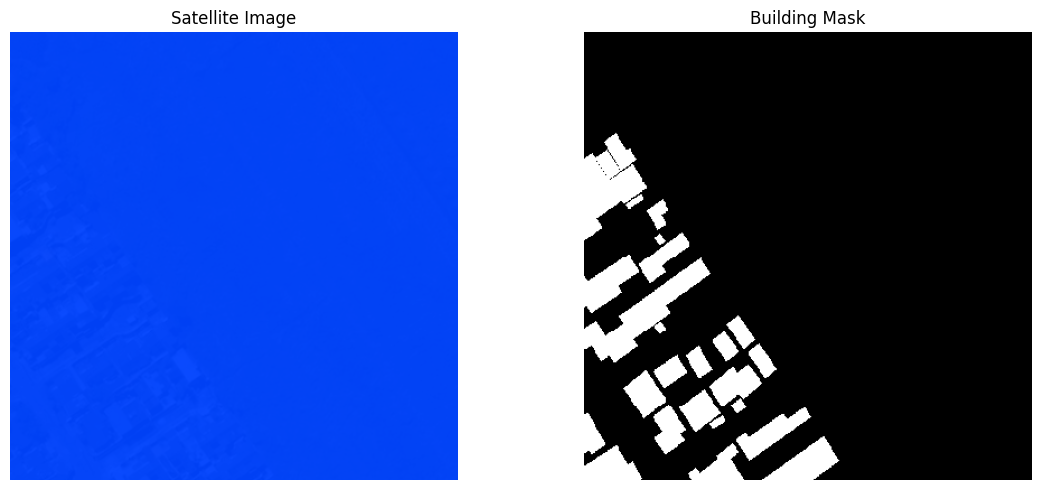

In [10]:
# --- Verify a batch looks correct ---
import matplotlib.pyplot as plt

images, masks = next(iter(train_loader))

print(f"Image batch shape : {images.shape}")    # (8, 3, H, W)
print(f"Mask batch shape  : {masks.shape}")     # (8, 1, H, W)
print(f"Image value range : {images.min():.2f} to {images.max():.2f}")
print(f"Mask unique values: {masks.unique()}")  # should be [0, 1]

# Visualize first sample in batch
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Image — undo normalization for display
img = images[0].permute(1, 2, 0).numpy()
img = (img - img.min()) / (img.max() - img.min())
axes[0].imshow(img)
axes[0].set_title("Satellite Image")
axes[0].axis('off')

# Mask
axes[1].imshow(masks[0].squeeze().numpy(), cmap='gray')
axes[1].set_title("Building Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# --- Install SAM ---
import subprocess
subprocess.run(['pip', 'install', 'segment-anything', '--quiet'])
print("✅ SAM installed!")

✅ SAM installed!


In [12]:
# --- Download SAM checkpoint (Windows-friendly) ---
import urllib.request
import os

url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
output = "./sam_vit_b_01ec64.pth"

if os.path.exists(output):
    print("✅ Checkpoint already exists, skipping download!")
else:
    print("Downloading SAM checkpoint (~375MB)... please wait")
    urllib.request.urlretrieve(url, output)
    print("✅ Download complete!")

✅ Checkpoint already exists, skipping download!


In [13]:
# --- Load SAM Model ---
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import torch

sam = sam_model_registry["vit_b"](checkpoint="./sam_vit_b_01ec64.pth")

device = "cuda" if torch.cuda.is_available() else "cpu"
sam.to(device)

print(f"✅ SAM loaded on {device}")

✅ SAM loaded on cuda


In [14]:
# --- Run SAM on a satellite image ---
import rasterio
import numpy as np
from segment_anything import SamAutomaticMaskGenerator

# Load a satellite image that has buildings
img_path = './SpaceNet1/train/3band/3band_AOI_1_RIO_img1009.tif'

with rasterio.open(img_path) as src:
    image = src.read([1, 2, 3])
    image = np.transpose(image, (1, 2, 0))
    image = np.clip(image, 0, 255).astype(np.uint8)

print(f"Image shape: {image.shape}")

# Generate masks automatically
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    min_mask_region_area=100,
)

masks = mask_generator.generate(image)
print(f"✅ SAM generated {len(masks)} masks")

Image shape: (406, 438, 3)
✅ SAM generated 17 masks


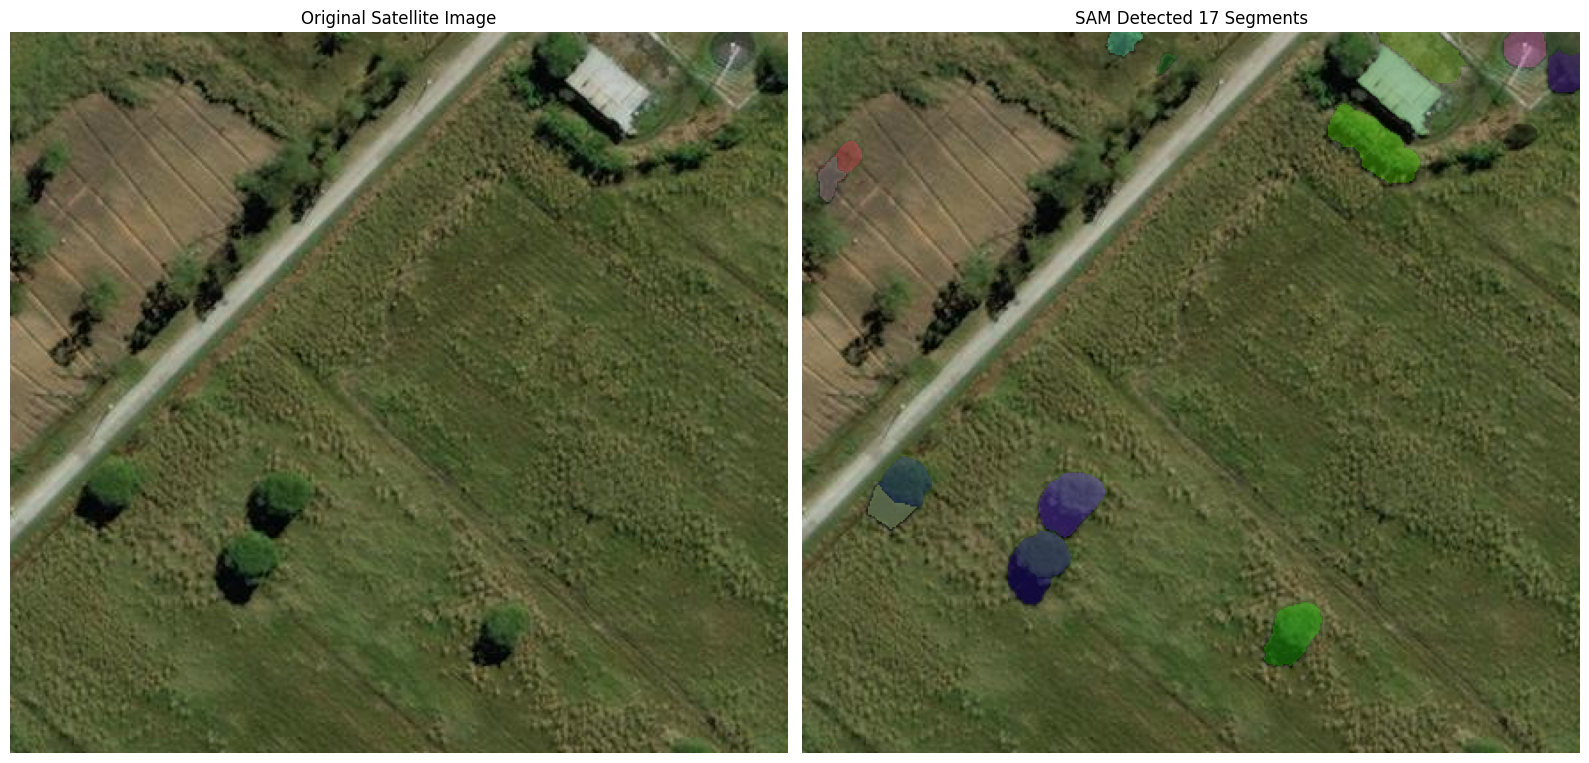

In [15]:
# --- Visualize SAM masks on satellite image ---
import matplotlib.pyplot as plt
import numpy as np

def show_sam_masks(image, masks):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(image)
    axes[0].set_title("Original Satellite Image")
    axes[0].axis('off')

    axes[1].imshow(image)
    for mask in masks:
        m = mask['segmentation']
        color = np.concatenate([np.random.random(3), [0.4]])
        overlay = np.zeros((*m.shape, 4))
        overlay[m] = color
        axes[1].imshow(overlay)
    axes[1].set_title(f"SAM Detected {len(masks)} Segments")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

show_sam_masks(image, masks)

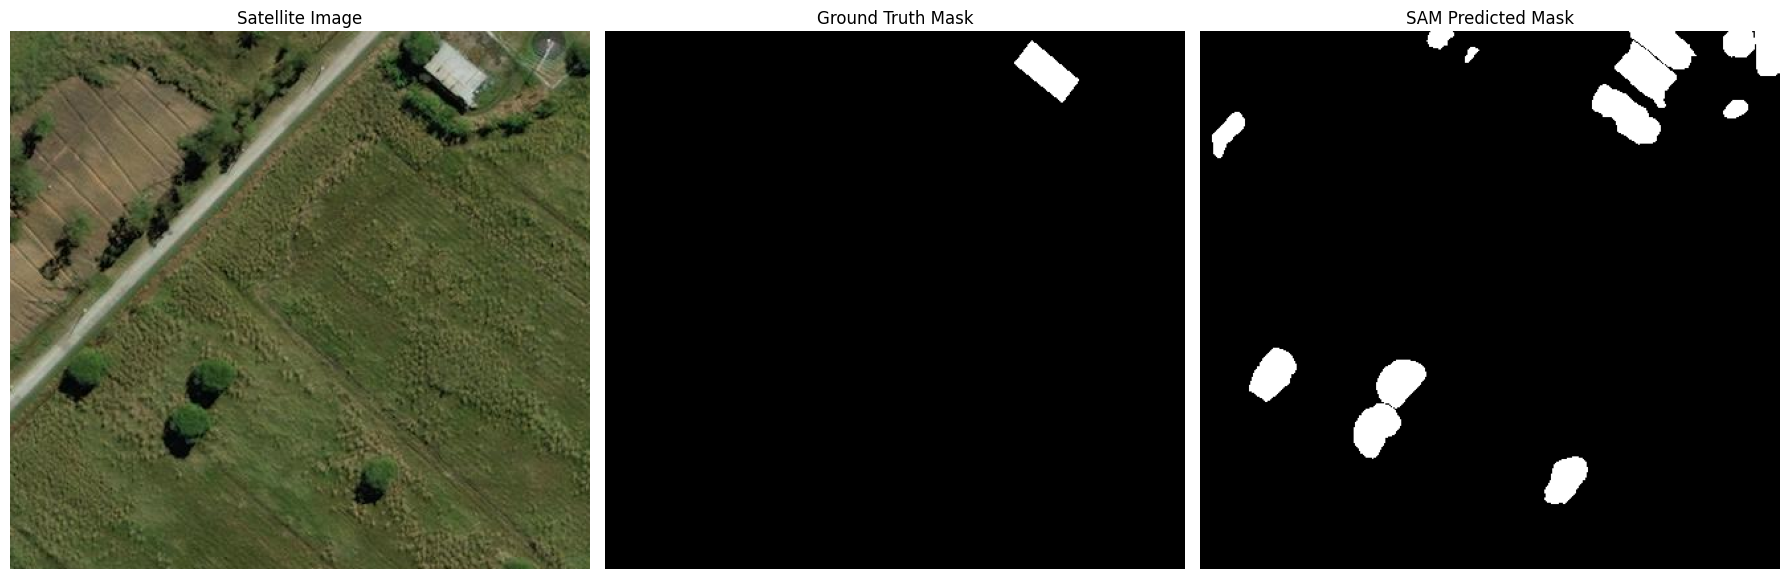

✅ IoU Score (SAM vs Ground Truth): 0.1025


In [17]:
# --- Compare SAM output vs Ground Truth mask ---
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load ground truth mask
mask_path = './SpaceNet1/train/masks/mask_AOI_1_RIO_img1009.tif'
with rasterio.open(mask_path) as src:
    gt_mask = src.read(1)

# Resize gt_mask to match image size if needed
from PIL import Image as PILImage
if gt_mask.shape != image.shape[:2]:
    gt_mask = np.array(PILImage.fromarray(gt_mask).resize(
        (image.shape[1], image.shape[0]), PILImage.NEAREST))

# Combine all SAM masks into one binary mask
sam_combined = np.zeros(image.shape[:2], dtype=np.uint8)
for m in masks:
    sam_combined[m['segmentation']] = 1

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Satellite Image")
axes[0].axis('off')

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

axes[2].imshow(sam_combined, cmap='gray')
axes[2].set_title("SAM Predicted Mask")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# IoU Score
intersection = np.logical_and(gt_mask, sam_combined).sum()
union        = np.logical_or(gt_mask, sam_combined).sum()
iou          = intersection / union if union > 0 else 0
print(f"✅ IoU Score (SAM vs Ground Truth): {iou:.4f}")

Original masks : 17
Filtered masks : 15


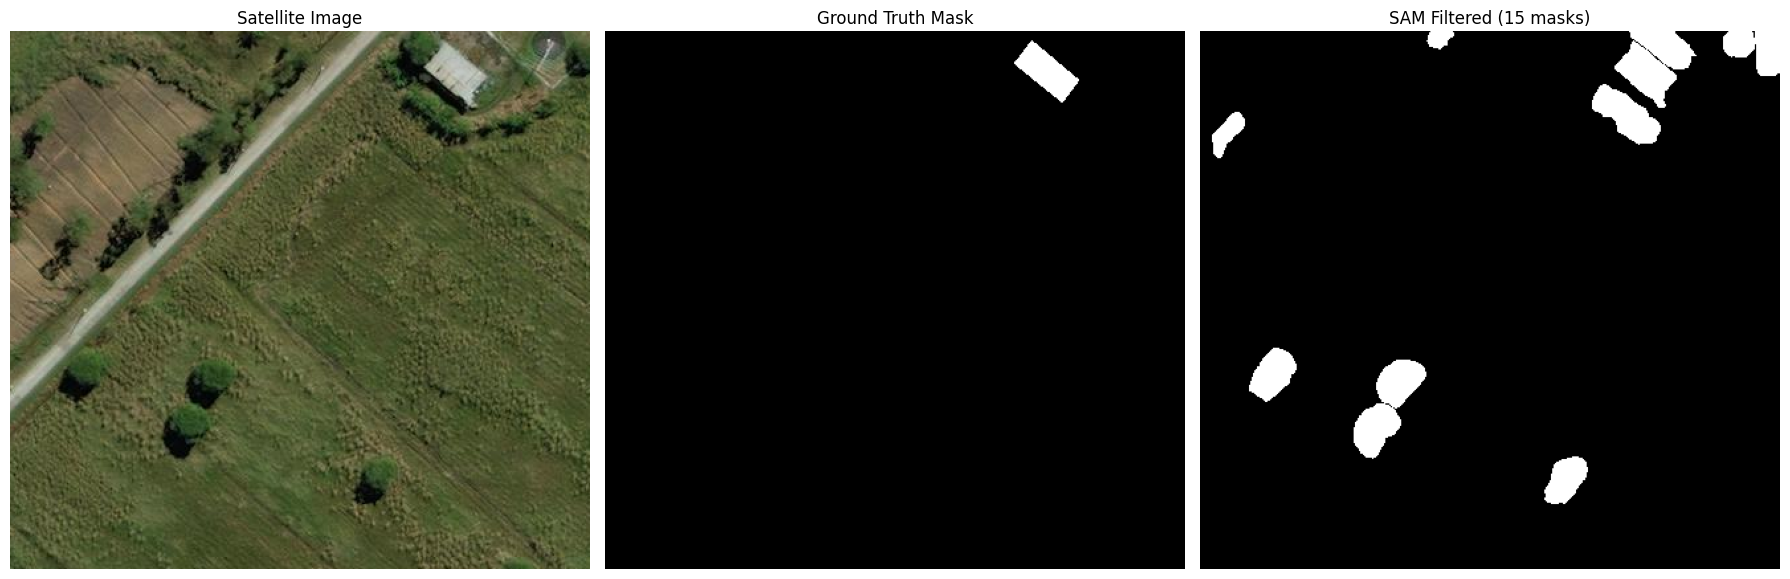

✅ Filtered IoU Score: 0.1057


In [18]:
# --- Filter SAM masks to keep only building-like segments ---
import numpy as np

def filter_building_masks(masks, image_shape,
                           min_area=200,
                           max_area=50000,
                           max_aspect_ratio=4.0):
    """Keep only masks that look like buildings."""
    filtered = []
    for m in masks:
        seg = m['segmentation']
        area = seg.sum()

        # Filter by area
        if area < min_area or area > max_area:
            continue

        # Filter by aspect ratio (buildings are roughly square)
        rows = np.any(seg, axis=1)
        cols = np.any(seg, axis=0)
        h = rows.sum()
        w = cols.sum()
        if h == 0 or w == 0:
            continue
        aspect_ratio = max(h, w) / min(h, w)
        if aspect_ratio > max_aspect_ratio:
            continue

        filtered.append(m)

    return filtered

# Apply filter
filtered_masks = filter_building_masks(masks, image.shape)
print(f"Original masks : {len(masks)}")
print(f"Filtered masks : {len(filtered_masks)}")

# Recalculate IoU with filtered masks
sam_filtered = np.zeros(image.shape[:2], dtype=np.uint8)
for m in filtered_masks:
    sam_filtered[m['segmentation']] = 1

# Plot updated comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Satellite Image")
axes[0].axis('off')

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')

axes[2].imshow(sam_filtered, cmap='gray')
axes[2].set_title(f"SAM Filtered ({len(filtered_masks)} masks)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# New IoU
intersection = np.logical_and(gt_mask, sam_filtered).sum()
union        = np.logical_or(gt_mask, sam_filtered).sum()
iou          = intersection / union if union > 0 else 0
print(f"✅ Filtered IoU Score: {iou:.4f}")

In [19]:
# --- Quick device check ---
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU


In [20]:
# --- U-Net Architecture ---
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)

        for feature in features:
            self.encoder.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feature in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(feature*2, feature, 2, 2))
            self.decoder.append(DoubleConv(feature*2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skip_connections = []
        for encode in self.encoder:
            x = encode(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x)
            skip = skip_connections[i//2]
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.decoder[i+1](x)
        return self.final_conv(x)

# Build model — no dummy input yet
model = UNet(in_channels=3, out_channels=1)
model = model.to(device)
print(f"✅ U-Net created on {device}!")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

✅ U-Net created on cuda!
Total parameters: 31,043,521


In [21]:
# --- Loss Function & Optimizer ---
import torch.optim as optim
import torch.nn as nn

# Binary Cross Entropy + Dice Loss combined
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        pred_sig = torch.sigmoid(pred)
        smooth = 1e-6
        intersection = (pred_sig * target).sum(dim=(2,3))
        dice_loss = 1 - (2 * intersection + smooth) / (
            pred_sig.sum(dim=(2,3)) + target.sum(dim=(2,3)) + smooth)
        return bce_loss + dice_loss.mean()

criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5, verbose=True)

print("✅ Loss function, optimizer and scheduler ready!")

✅ Loss function, optimizer and scheduler ready!


c:\IDEAS_OverheadImageUndersatnding\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [22]:
# --- Clear GPU Memory ---
import torch, gc
torch.cuda.empty_cache()
gc.collect()

model = UNet(in_channels=3, out_channels=1)
model = model.to(device)

import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # ← added weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5)

print("✅ Model reinitialized with regularization!")

✅ Model reinitialized with regularization!


In [23]:
# --- Pre-load data into RAM (faster training) ---
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

print("Pre-loading images into RAM... please wait")

all_images, all_masks = [], []

# Load only 500 samples
indices = np.random.choice(len(full_dataset), 500, replace=False)

for i, idx in enumerate(indices):
    img, mask = full_dataset[idx]
    all_images.append(img)
    all_masks.append(mask)
    if (i+1) % 50 == 0:
        print(f"  Loaded {i+1}/200...")

# Stack into tensors
images_tensor = torch.stack(all_images)  # (200, 3, 400, 400)
masks_tensor  = torch.stack(all_masks)   # (200, 1, 400, 400)

print(f"Images tensor shape : {images_tensor.shape}")
print(f"Masks tensor shape  : {masks_tensor.shape}")

# Create TensorDataset (everything in RAM)
tensor_dataset = TensorDataset(images_tensor, masks_tensor)

# 80/20 split
train_size = 400
val_size   = 100

ram_train, ram_val = torch.utils.data.random_split(
    tensor_dataset, [train_size, val_size])

ram_train_loader = DataLoader(ram_train, batch_size=4,
                               shuffle=True,  num_workers=0)
ram_val_loader   = DataLoader(ram_val,   batch_size=4,
                               shuffle=False, num_workers=0)

print(f"✅ Data in RAM!")
print(f"Train batches : {len(ram_train_loader)}")
print(f"Val batches   : {len(ram_val_loader)}")

Pre-loading images into RAM... please wait
  Loaded 50/200...
  Loaded 100/200...
  Loaded 150/200...
  Loaded 200/200...
  Loaded 250/200...
  Loaded 300/200...
  Loaded 350/200...
  Loaded 400/200...
  Loaded 450/200...
  Loaded 500/200...
Images tensor shape : torch.Size([500, 3, 400, 400])
Masks tensor shape  : torch.Size([500, 1, 400, 400])
✅ Data in RAM!
Train batches : 100
Val batches   : 25


In [24]:
# --- IoU Score Function ---
import torch

def iou_score(pred, target, threshold=0.5):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(2,3))
    union = (pred_bin + target).clamp(0,1).sum(dim=(2,3))
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

print("✅ iou_score function defined!")

✅ iou_score function defined!


In [25]:
# --- Training Loop (RAM VERSION - FAST) ---
import torch

NUM_EPOCHS = 10
best_val_loss = float('inf')
train_losses, val_losses, val_ious = [], [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0
    for images, masks in ram_train_loader:
        images = images.to(device)
        masks  = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(ram_train_loader)
    train_losses.append(train_loss)

    # --- Validation ---
    model.eval()
    val_loss, val_iou = 0, 0
    with torch.no_grad():
        for images, masks in ram_val_loader:
            images = images.to(device)
            masks  = masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks).item()
            val_iou  += iou_score(outputs, masks)

    val_loss /= len(ram_val_loader)
    val_iou  /= len(ram_val_loader)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_unet.pth')
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val IoU: {val_iou:.4f} ⭐ saved")
    else:
        print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val IoU: {val_iou:.4f}")

print("\n✅ Training complete!")
print(f"Best Val Loss : {best_val_loss:.4f}")
print(f"Best Val IoU  : {max(val_ious):.4f}")

Epoch 01/10 | Train Loss: 1.3523 | Val Loss: 3.0729 | Val IoU: 0.1145 ⭐ saved
Epoch 02/10 | Train Loss: 1.2292 | Val Loss: 3.8658 | Val IoU: 0.1142
Epoch 03/10 | Train Loss: 1.1879 | Val Loss: 4.0839 | Val IoU: 0.1143
Epoch 04/10 | Train Loss: 1.1589 | Val Loss: 1.2768 | Val IoU: 0.0000 ⭐ saved
Epoch 05/10 | Train Loss: 1.1245 | Val Loss: 1.2774 | Val IoU: 0.2800
Epoch 06/10 | Train Loss: 1.1012 | Val Loss: 9.3859 | Val IoU: 0.1143
Epoch 07/10 | Train Loss: 1.0807 | Val Loss: 9.1827 | Val IoU: 0.1142
Epoch 08/10 | Train Loss: 1.0538 | Val Loss: 1.2065 | Val IoU: 0.2187 ⭐ saved
Epoch 09/10 | Train Loss: 1.0335 | Val Loss: 1.3128 | Val IoU: 0.2818
Epoch 10/10 | Train Loss: 1.0233 | Val Loss: 8.2590 | Val IoU: 0.1145

✅ Training complete!
Best Val Loss : 1.2065
Best Val IoU  : 0.2818


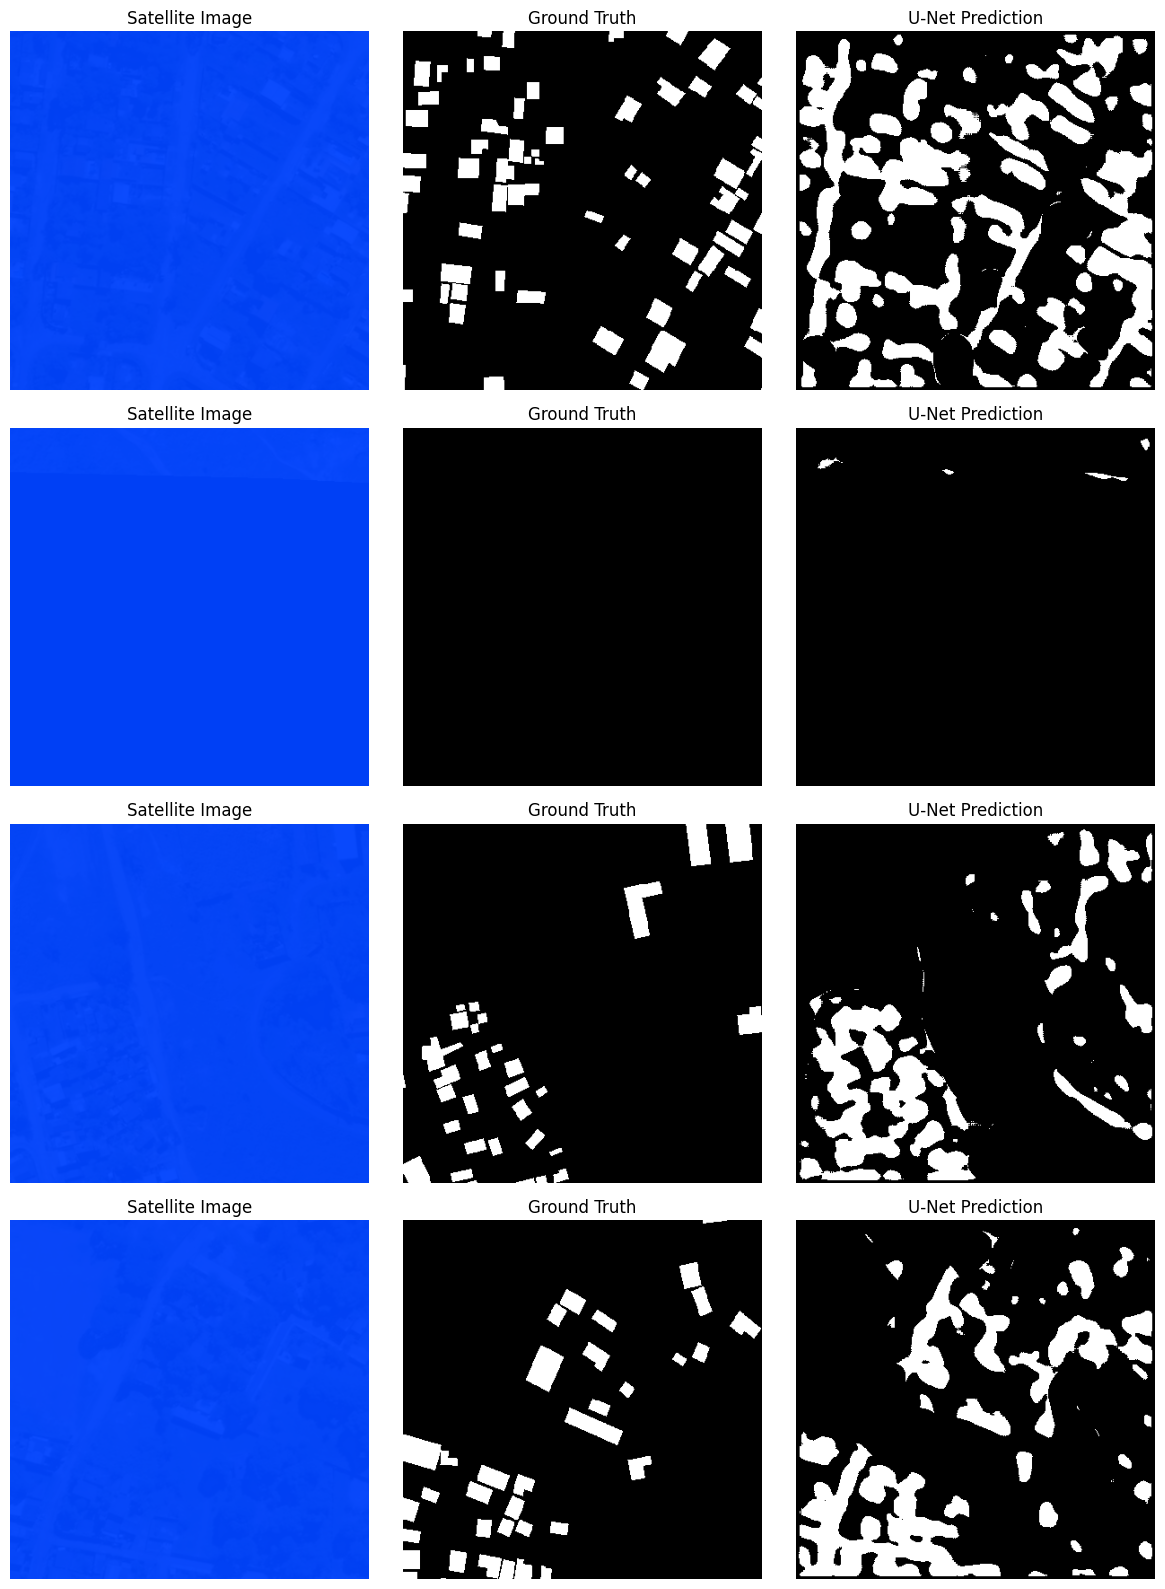

In [26]:
# --- Visualize U-Net Predictions ---
import matplotlib.pyplot as plt
import torch
import numpy as np

# Load best model
model.load_state_dict(torch.load('best_unet.pth'))
model.eval()

# Get a batch from val loader
images, masks = next(iter(ram_val_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.sigmoid(outputs).cpu()
    preds_bin = (preds > 0.5).float()

# Plot 4 examples
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for i in range(4):
    img = images[i].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[i][0].imshow(img)
    axes[i][0].set_title("Satellite Image")
    axes[i][0].axis('off')

    axes[i][1].imshow(masks[i].squeeze().numpy(), cmap='gray')
    axes[i][1].set_title("Ground Truth")
    axes[i][1].axis('off')

    axes[i][2].imshow(preds_bin[i].squeeze().numpy(), cmap='gray')
    axes[i][2].set_title("U-Net Prediction")
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()